<a href="https://colab.research.google.com/github/zebanahvi/machine-learning-projects/blob/main/EDA_HousingValue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Author: Zeba Nahvi
Tested with Python 3.12
06/19/2026

Information clarifying the features in the Boston Housing Dataset:
1. crim - per capita crime rate by town
2. zn - proportion of residential land zoned for lots over 25,000 sq. ft.
3. indus - proportion of non-retail business acres per town
4. chas - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
5. nox - nitric oxides concentration (parts per 10 million)
6. rm - average number of rooms per dwelling
7. age - proportion of owner-occupied units built prior to 1940
8. dis - weighted distances to five Boston employment centres
9. rad - index of accessibility to radial highways
10. tax - full-value property-tax rate per $10,000
11. ptratio - pupil-teacher ratio by town
12. b - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13. lstat - % lower status of the population
14. medv - median value of owner-occupied homes in $1000's
"""

"\nAuthor: Zeba Nahvi\nTested with Python 3.12\n06/19/2026\n\nInformation clarifying the features in the Boston Housing Dataset:\n1. crim - per capita crime rate by town\n2. zn - proportion of residential land zoned for lots over 25,000 sq. ft.\n3. indus - proportion of non-retail business acres per town\n4. chas - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\n5. nox - nitric oxides concentration (parts per 10 million)\n6. rm - average number of rooms per dwelling\n7. age - proportion of owner-occupied units built prior to 1940\n8. dis - weighted distances to five Boston employment centres\n9. rad - index of accessibility to radial highways\n10. tax - full-value property-tax rate per $10,000\n11. ptratio - pupil-teacher ratio by town\n12. b - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\n13. lstat - % lower status of the population\n14. medv - median value of owner-occupied homes in $1000's\n"

In [ ]:
from fileinput import filename

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import set_option
from pandas import read_csv
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from numpy import set_printoptions
import seaborn as sns
from pandas.plotting import scatter_matrix

In [ ]:
filePath = "/content/"
filename = 'boston.csv'
data1 = read_csv(filePath+filename)
names = ['Unnamed: 0','crim','zn', 'indus','chas','nox','rm','age','dis','rad', 'tax', 'ptratio','black', 'lstat', 'medv']
df2 = data1.drop(columns=['Unnamed: 0'], axis=1)

# save features as pandas dataframe for stepwise feature selection
X1 = data1.drop(['Unnamed: 0', 'medv'], axis = 1)
Y1 = data1['medv']
X1names = X1.columns

scaler1 = StandardScaler().fit(X1)
rescaledX1 = scaler1.transform(X1)

# summarize transformed data
set_printoptions(precision=3)
print(rescaledX1[0:5,:])

[[-0.42   0.285 -1.288 -0.273 -0.144  0.414 -0.12   0.14  -0.983 -0.667
  -1.459  0.441 -1.076]
 [-0.417 -0.488 -0.593 -0.273 -0.74   0.194  0.367  0.557 -0.868 -0.987
  -0.303  0.441 -0.492]
 [-0.417 -0.488 -0.593 -0.273 -0.74   1.283 -0.266  0.557 -0.868 -0.987
  -0.303  0.396 -1.209]
 [-0.417 -0.488 -1.307 -0.273 -0.835  1.016 -0.81   1.078 -0.753 -1.106
   0.113  0.416 -1.362]
 [-0.412 -0.488 -1.307 -0.273 -0.835  1.229 -0.511  1.078 -0.753 -1.106
   0.113  0.441 -1.027]]


In [ ]:
# making a new data frame with the standardized data
dataStandDf = pd.DataFrame(rescaledX1, columns = X1names)
dataStandDf['medv'] = Y1.values

# Looking at the data
peek = df2.head(5)
print(peek)

# descriptive statistics: mean, max, min, count, 25th percentile, 50th percentile
set_option('display.width', 100)
set_option('display.precision',1)
description = df2.describe()
print(f'DESCRIPTIVE STATS OF THE ORIGINAL DATA:\n{description}')

# show descriptive statistics after standardization
set_option('display.width', 100)
set_option('display.precision',1)
descriptionStand = dataStandDf.describe()
print(f'DESCRIPTIVE STATS OF THE STANDARDIZED DATA: \n{descriptionStand}')

      crim    zn  indus  chas  nox   rm   age  dis  rad  tax  ptratio  black  lstat  medv
0  6.3e-03  18.0    2.3     0  0.5  6.6  65.2  4.1    1  296     15.3  396.9    5.0  24.0
1  2.7e-02   0.0    7.1     0  0.5  6.4  78.9  5.0    2  242     17.8  396.9    9.1  21.6
2  2.7e-02   0.0    7.1     0  0.5  7.2  61.1  5.0    2  242     17.8  392.8    4.0  34.7
3  3.2e-02   0.0    2.2     0  0.5  7.0  45.8  6.1    3  222     18.7  394.6    2.9  33.4
4  6.9e-02   0.0    2.2     0  0.5  7.1  54.2  6.1    3  222     18.7  396.9    5.3  36.2
DESCRIPTIVE STATS OF THE ORIGINAL DATA:
          crim     zn  indus     chas    nox     rm    age    dis    rad    tax  ptratio  black  \
count  5.1e+02  506.0  506.0  5.1e+02  506.0  506.0  506.0  506.0  506.0  506.0    506.0  506.0   
mean   3.6e+00   11.4   11.1  6.9e-02    0.6    6.3   68.6    3.8    9.5  408.2     18.5  356.7   
std    8.6e+00   23.3    6.9  2.5e-01    0.1    0.7   28.1    2.1    8.7  168.5      2.2   91.3   
min    6.3e-03    0.0   

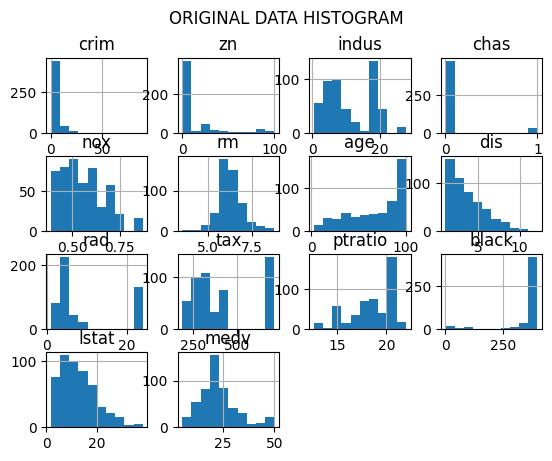

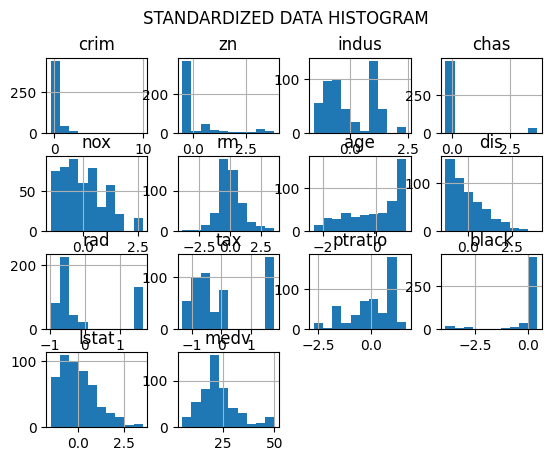

[[1.264e-05 3.600e-02 4.620e-03 0.000e+00 1.076e-03 1.315e-02 1.304e-01
  8.179e-03 2.000e-03 5.919e-01 3.060e-02 7.937e-01 9.959e-03]
 [5.785e-05 0.000e+00 1.498e-02 0.000e+00 9.935e-04 1.360e-02 1.671e-01
  1.052e-02 4.237e-03 5.126e-01 3.771e-02 8.408e-01 1.936e-02]
 [5.857e-05 0.000e+00 1.517e-02 0.000e+00 1.007e-03 1.542e-02 1.311e-01
  1.066e-02 4.293e-03 5.194e-01 3.820e-02 8.431e-01 8.650e-03]
 [7.105e-05 0.000e+00 4.785e-03 0.000e+00 1.005e-03 1.536e-02 1.005e-01
  1.331e-02 6.585e-03 4.873e-01 4.104e-02 8.662e-01 6.453e-03]
 [1.506e-04 0.000e+00 4.755e-03 0.000e+00 9.989e-04 1.559e-02 1.182e-01
  1.322e-02 6.543e-03 4.842e-01 4.078e-02 8.656e-01 1.162e-02]]
          crim       zn    indus     chas      nox       rm      age      dis      rad    tax  \
count  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  506.0   
mean   5.1e-03  2.3e-02  1.9e-02  1.3e-04  9.9e-04  1.2e-02  1.2e-01  7.3e-03  1.5e-02    0.7   
std    1.2e-02  4.7e-02  1.1e-02 

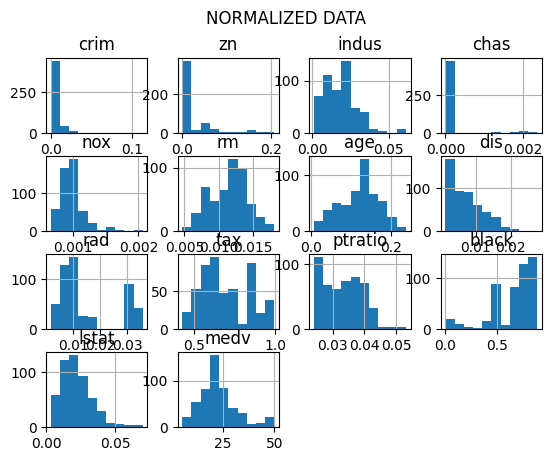

In [ ]:
# we look at the distribution of data and its descriptive statistics
df2.hist()
plt.suptitle("ORIGINAL DATA HISTOGRAM")
plt.show()

# showing the histogram after standardization
dataStandDf.hist()
plt.suptitle("STANDARDIZED DATA HISTOGRAM")
plt.show()

# separate array into input and output components
scaler = Normalizer().fit(X1)
normalizedX = scaler.transform(X1)
# summarize transformed data
set_printoptions(precision=3)
print(normalizedX[0:5,:])

# you can make a new data frame with the normalized data
dataNormDf = pd.DataFrame(normalizedX,columns = X1names)
dataNormDf['medv'] = Y1.values

# show descriptive stats after normalization
set_option('display.width', 100)
set_option('display.precision',1)
descriptionNorm = dataNormDf.describe()
print(descriptionNorm)

# we look at the distribution of data and its descriptive statistics
dataNormDf.hist()
plt.suptitle("NORMALIZED DATA")
plt.show()

            crim       zn    indus     chas      nox       rm      age      dis      rad      tax  \
crim     1.0e+00 -2.0e-01  4.1e-01 -5.6e-02  4.2e-01 -2.2e-01  3.5e-01 -3.8e-01  6.3e-01  5.8e-01   
zn      -2.0e-01  1.0e+00 -5.3e-01 -4.3e-02 -5.2e-01  3.1e-01 -5.7e-01  6.6e-01 -3.1e-01 -3.1e-01   
indus    4.1e-01 -5.3e-01  1.0e+00  6.3e-02  7.6e-01 -3.9e-01  6.4e-01 -7.1e-01  6.0e-01  7.2e-01   
chas    -5.6e-02 -4.3e-02  6.3e-02  1.0e+00  9.1e-02  9.1e-02  8.7e-02 -9.9e-02 -7.4e-03 -3.6e-02   
nox      4.2e-01 -5.2e-01  7.6e-01  9.1e-02  1.0e+00 -3.0e-01  7.3e-01 -7.7e-01  6.1e-01  6.7e-01   
rm      -2.2e-01  3.1e-01 -3.9e-01  9.1e-02 -3.0e-01  1.0e+00 -2.4e-01  2.1e-01 -2.1e-01 -2.9e-01   
age      3.5e-01 -5.7e-01  6.4e-01  8.7e-02  7.3e-01 -2.4e-01  1.0e+00 -7.5e-01  4.6e-01  5.1e-01   
dis     -3.8e-01  6.6e-01 -7.1e-01 -9.9e-02 -7.7e-01  2.1e-01 -7.5e-01  1.0e+00 -4.9e-01 -5.3e-01   
rad      6.3e-01 -3.1e-01  6.0e-01 -7.4e-03  6.1e-01 -2.1e-01  4.6e-01 -4.9e-01  1.0e+00  9

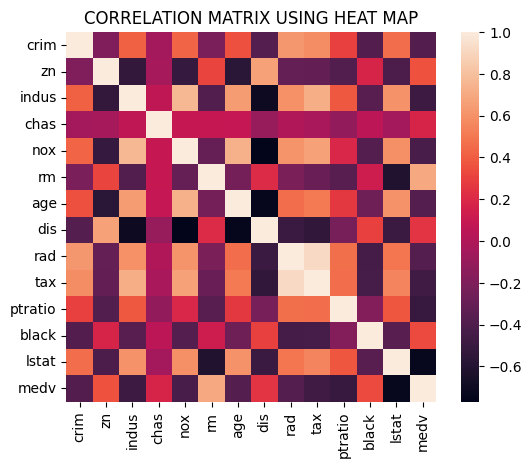

<Figure size 640x480 with 0 Axes>

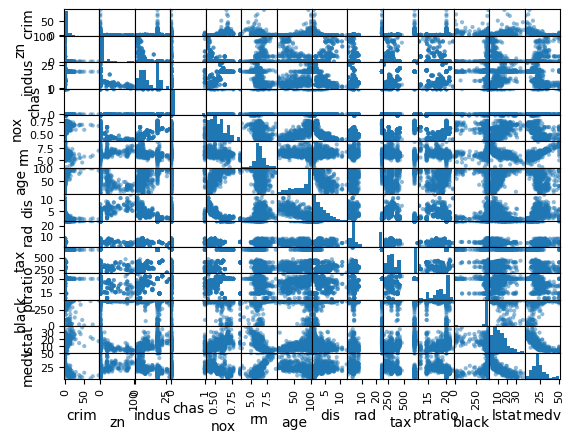

In [ ]:
# correlation heat map, pay attention to the correlation b/w all features and each predictor and the output
plt.figure() # new plot
corMat = df2.corr(method = 'pearson')
print(corMat)
# plot correlation matrix as a heat map
sns.heatmap(corMat, square= True)
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.title("CORRELATION MATRIX USING HEAT MAP")
plt.show()

# scatter plot of all data
plt.figure()
plt.suptitle("SCATTER MATRIX")
scatter_matrix(df2)
plt.show()